                              feature  importance
1                 numeric__Attendance    0.450743
0              numeric__Hours_Studied    0.277573
3            numeric__Previous_Scores    0.050780
9        ordinal__Access_to_Resources    0.043552
6       ordinal__Parental_Involvement    0.040070
4          numeric__Tutoring_Sessions    0.035662
11             ordinal__Family_Income    0.014919
13            ordinal__Peer_Influence    0.013571
12           ordinal__Teacher_Quality    0.013071
8   ordinal__Parental_Education_Level    0.011701


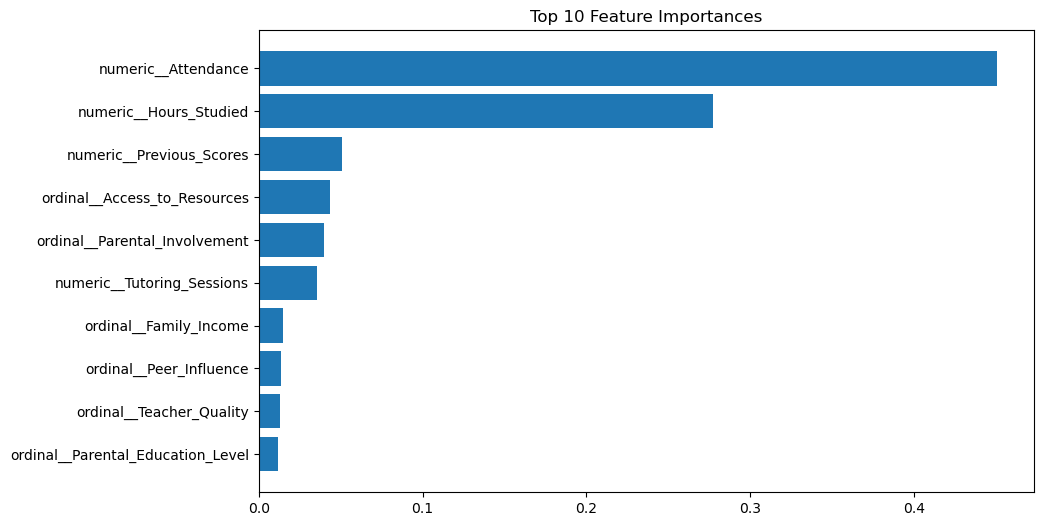

0.6843420953634836
1.8896203453417295
0.7473896892756802
1.7.2


In [2]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from  sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/StudentPerformanceFactors.csv")
X = df.drop('Exam_Score',axis=1)
y= df['Exam_Score']

numeric_cols=['Hours_Studied', 'Attendance',   'Sleep_Hours',
       'Previous_Scores',  'Tutoring_Sessions','Physical_Activity']
                  
ordinal_cols=['Parental_Involvement','Distance_from_Home','Parental_Education_Level',
       'Access_to_Resources','Motivation_Level','Family_Income', 'Teacher_Quality','Peer_Influence']

nominal_cols=['Learning_Disabilities','School_Type','Extracurricular_Activities',
               'Gender','Internet_Access']

low_medium_high=['Low','Medium','High']

education_order=['High School','College','Postgraduate']

distance_order=['Near','Moderate','Far']

peer_influence_order=['Negative','Neutral','Positive']

ordinal_categories=[
    low_medium_high,distance_order,education_order,low_medium_high,low_medium_high,low_medium_high,
    low_medium_high,peer_influence_order
]


numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=ordinal_categories))
])

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor=ColumnTransformer(
    transformers=[
        ('numeric',numeric_pipeline,numeric_cols),
        ('ordinal',ordinal_pipeline,ordinal_cols),
        ('nominal',nominal_pipeline,nominal_cols)
    ])

pipeline =Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',GradientBoostingRegressor(n_estimators=300,learning_rate=0.05,random_state=42))
])

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)
pipeline.fit(X_train,y_train)
y_predit = pipeline.predict(X_test)

mae = mean_absolute_error(y_test,y_predit)
rmse = np.sqrt(mean_squared_error(y_test,y_predit))
r2 = r2_score(y_test,y_predit)

# get feature names after preprocessing
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

importances = pipeline.named_steps['regressor'].feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feat_imp = feat_imp.sort_values(by="importance", ascending=False)
print(feat_imp.head(10))

plt.figure(figsize=(10,6))
plt.barh(feat_imp["feature"][:10][::-1], feat_imp["importance"][:10][::-1])
plt.title("Top 10 Feature Importances")
plt.show()

print(mae)
print(rmse)
print(r2)

import sklearn
print(sklearn.__version__)








In [3]:
import sys
print(sys.executable)

c:\Users\dator\anaconda3\python.exe


In [22]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [7]:
df['Exam_Score'].mean()
df['Exam_Score'].describe()



count    6607.000000
mean       67.231421
std         3.869956
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

In [8]:
df[df["Exam_Score"] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101
